In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
from transformers import T5ForConditionalGeneration, T5Tokenizer, Seq2SeqTrainer, Seq2SeqTrainingArguments, AutoModelForSeq2SeqLM
from datasets import Dataset
from sklearn.model_selection import train_test_split
from rouge import Rouge
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, pipeline, EarlyStoppingCallback
import evaluate
from wordcloud import WordCloud

c:\Users\PC\anaconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
df = pd.read_csv('IndoData200.csv')

In [4]:
df.head()

,article,summary
0,"Lukisan bunga Van Gogh terjual US$61,8 juta.\r...","Sebuah mahakarya Vincent van Gogh, yang diluki..."
1,Mengapa pengungsi Suriah diminta segera mening...,Ribuan pengungsi Suriah punya waktu hingga Sel...
2,Para pemain Chapecoense akan dikenang selamany...,"Ribuan orang berkumpul di kota Chapeco, Brasil..."
3,Kelompok Kurdi TAK klaim mengebom Ankara.\r\nD...,Kelompok militan Kurdi TAK mengatakan pihaknya...
4,Virus corona: Sejumlah dokter di India ‘diluda...,Sejumlah tenaga kesehatan di India dilaporkan ...


In [5]:
df.isnull().sum()

article    0
summary    0
dtype: int64

In [6]:
df.duplicated(subset=['article']).sum()

0

In [7]:
df['article_length'] = df['article'].str.split().str.len()
df['summary_length'] = df['summary'].str.split().str.len()

print(df[['article_length', 'summary_length']].describe())

       article_length  summary_length
count       200.00000      200.000000
mean        358.13000       21.490000
std         228.75629        5.296239
min         116.00000       11.000000
25%         205.00000       18.000000
50%         277.50000       21.000000
75%         424.25000       24.250000
max        1379.00000       38.000000


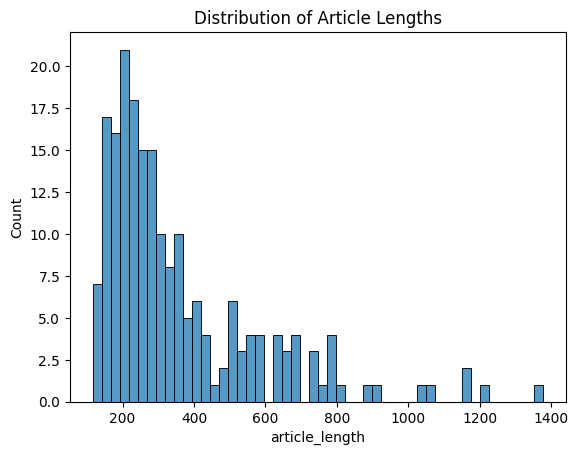

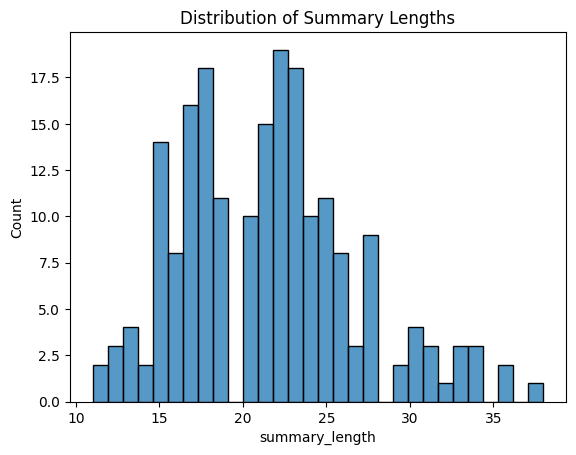

In [8]:
sns.histplot(df['article_length'], bins=50)
plt.title('Distribution of Article Lengths')
plt.show()

sns.histplot(df['summary_length'], bins=30)
plt.title('Distribution of Summary Lengths')
plt.show()

In [9]:
rouge = evaluate.load('rouge')

results = rouge.compute(predictions=df['summary'].tolist(), references=df['article'].tolist())

# Print the scores
print("ROUGE Scores between Article and Summary:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

ROUGE Scores between Article and Summary:
rouge1: 0.0962
rouge2: 0.0358
rougeL: 0.0692
rougeLsum: 0.0733


In [10]:
df['article'] = df['article'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['summary'] = df['summary'].str.replace(r'\s+', ' ', regex=True).str.strip()

all_text = ' '.join(df['article'].dropna())

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
).generate(all_text)



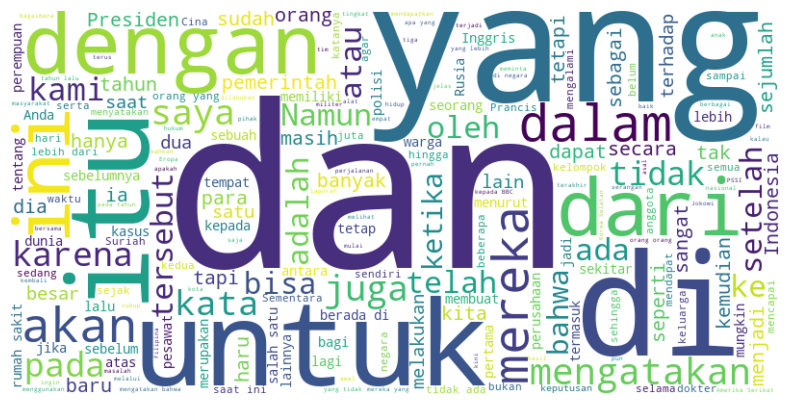

In [11]:
plt.figure(figsize=(10, 5)) # Set the figure size
plt.imshow(wordcloud, interpolation='bilinear') # Display the image
plt.axis("off") # Hide the x and y axes
plt.show()

In [12]:
model_name = "gaduhhartawan/indobart-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

c:\Users\PC\anaconda3\envs\myenv\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [13]:
train_dataset, temp_dataset = train_test_split(df, test_size=0.2, random_state=42)

val_dataset, test_dataset = train_test_split(temp_dataset, test_size=0.5, random_state=42)

In [14]:
train_dataset = Dataset.from_pandas(train_dataset)
val_dataset = Dataset.from_pandas(val_dataset)
test_dataset = Dataset.from_pandas(test_dataset)

In [15]:
def preprocess_function(examples):
    inputs = tokenizer(
        examples["article"], max_length=1024, truncation=True, padding="max_length"
    )
    
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["summary"], max_length=64, truncation=True, padding="max_length"
        )
    
    # The model needs to know what the "correct answer" is. We assign it to the 'labels' key.
    inputs["labels"] = labels["input_ids"]
    return inputs

In [16]:
## See if the preprocessing works correctly

sample = train_dataset[0]

processed_sample = preprocess_function({
    "article": [sample["article"]],
    "summary": [sample["summary"]]
})

decoded_article = tokenizer.decode(
    processed_sample['input_ids'][0], 
    skip_special_tokens=True
)
decoded_summary = tokenizer.decode(
    processed_sample['labels'][0], 
    skip_special_tokens=True
)

print("--- ORIGINAL ARTICLE ---")
print(sample["article"])
print("\n--- PROCESSED & DECODED ARTICLE ---")
print(decoded_article)
print("\n" + "="*50 + "\n")
print("--- ORIGINAL SUMMARY ---")
print(sample["summary"])
print("\n--- PROCESSED & DECODED SUMMARY` ---")
print(decoded_summary)

--- ORIGINAL ARTICLE ---
Layanan teknologi untuk tradisi 'menyapu makam' warga Cina. Beberapa taman pemakaman di Cina menawarkan kode QR untuk mendapatkan foto maupun video dari makam para leluhur. Dikenal juga sebagai 'menyapu makam', dalam upacara ini orang-orang akan membersihkan makam dan memberi persembahan kepada roh leluhur maupun anggota keluarga tercinta. Namun dalam beberapa tahun belakangan, teknologi juga mulai memasuki tradisi yang sudah berlangsung selama berabad-abad. Untuk upacara tahun ini, misalnya, satu taman pemakaman di Nanjing, ibu kota Provinsi Jiansu di sebelah timur Cina, menawarkan jasa 'pelayat' dan sekaligus pembersih makam, seperti dilaporkan Beijing News. Jika Anda tidak bisa datang ke makam, maka karyawan di pemakaman Yuhuatai Gongdeyuan akan membersihkan makan dan menaruh bunga untuk para pelanggan, yang menyaksikannya lewat video siaran langsung di aplikasi media sosial Wechat. Menyewa para pelayat profesional memang menjadi semakin populer karena tidak

c:\Users\PC\anaconda3\envs\myenv\lib\site-packages\transformers\tokenization_utils_base.py:3892: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [17]:
import transformers
import accelerate
print(transformers.__version__)
print(accelerate.__version__)

4.38.2
0.27.2


In [18]:
# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred
#     decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
#     # Replace -100 in the labels as we can't decode them.
#     labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
#     decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
#     # ROUGE scoring
#     # We will get a dictionary of scores
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
#     # We need to calculate ROUGE for each prediction/label pair and then average
#     # A simple way to do this is with a loop
#     scores = [scorer.score(p, l) for p, l in zip(decoded_preds, decoded_labels)]
    
#     # Now, extract the F1-scores and average them
#     result = {
#         'rouge1': np.mean([s['rouge1'].fmeasure for s in scores]),
#         'rouge2': np.mean([s['rouge2'].fmeasure for s in scores]),
#         'rougeL': np.mean([s['rougeL'].fmeasure for s in scores]),
#     }

#     # Return a dictionary with just the F1 scores
#     return result

In [19]:
def compute_rouge_metrics(predictions, references):
    """Compute ROUGE metrics with better error handling"""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
    
    for pred, ref in zip(predictions, references):
        # Ensure both pred and ref are strings and not empty
        pred = str(pred).strip() if pred else "empty"
        ref = str(ref).strip() if ref else "empty"
        
        # Skip empty predictions/references to avoid ROUGE errors
        if not pred or not ref:
            rouge1_scores.append(0.0)
            rouge2_scores.append(0.0)
            rougeL_scores.append(0.0)
            continue
            
        try:
            scores = scorer.score(ref, pred)
            rouge1_scores.append(float(scores['rouge1'].fmeasure))
            rouge2_scores.append(float(scores['rouge2'].fmeasure))
            rougeL_scores.append(float(scores['rougeL'].fmeasure))
        except Exception as e:
            print(f"ROUGE computation error for pred='{pred}', ref='{ref}': {e}")
            rouge1_scores.append(0.0)
            rouge2_scores.append(0.0)
            rougeL_scores.append(0.0)
    
    return {
        'rouge1': float(np.mean(rouge1_scores)),
        'rouge2': float(np.mean(rouge2_scores)),
        'rougeL': float(np.mean(rougeL_scores))
    }

def compute_metrics(eval_preds):
    """Compute metrics for evaluation with improved error handling"""
    try:
        predictions, labels = eval_preds
        
        # Handle different prediction formats
        if isinstance(predictions, tuple):
            predictions = predictions[0]
        
        # Ensure predictions are in the right format and convert to numpy
        predictions = np.array(predictions)
        labels = np.array(labels)
        
        # Handle potential overflow in predictions by clipping values
        vocab_size = tokenizer.vocab_size
        predictions = np.clip(predictions, 0, vocab_size - 1)
        
        # Convert any potential float predictions to integers
        predictions = predictions.astype(np.int32)
        
        # Decode predictions
        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        
        # Handle labels - replace -100 with pad_token_id
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        labels = labels.astype(np.int32)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        
        # Clean up decoded text
        decoded_preds = [str(pred).strip() for pred in decoded_preds]
        decoded_labels = [str(label).strip() for label in decoded_labels]
        
        # Compute ROUGE metrics
        rouge_metrics = compute_rouge_metrics(decoded_preds, decoded_labels)
        
        return rouge_metrics
    
    except Exception as e:
        print(f"Error in compute_metrics: {e}")
        return {
            'rouge1': 0.0,
            'rouge2': 0.0,
            'rougeL': 0.0
        }

In [20]:
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched= True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

training_args = Seq2SeqTrainingArguments(
    output_dir=f'./results_{model_name.replace("/", "_")}',
    evaluation_strategy="epoch",
    learning_rate=1e-5,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4, 
    num_train_epochs=15,
    weight_decay=0.01,
    save_total_limit=2,
    save_strategy="epoch",
    predict_with_generate=True,
    fp16=True, 
    report_to="none",
    warmup_steps = 0,
    eval_accumulation_steps=1,
    logging_dir=f'./logs_{model_name.replace("/", "_")}',
    logging_strategy="steps",
    logging_steps= 20
)

Map: 100%|██████████| 20/20 [00:00<00:00, 1257.30 examples/s]


In [21]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01) if 'EarlyStoppingCallback' in globals() else None]   
)

In [ ]:
trainer.train()

  0%|          | 0/300 [00:00<?, ?it/s]c:\Users\PC\anaconda3\envs\myenv\lib\site-packages\transformers\models\bart\modeling_bart.py:590: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
  7%|▋         | 20/300 [00:32<07:05,  1.52s/it]

{'loss': 1.7958, 'grad_norm': 3.475701093673706, 'learning_rate': 9.366666666666668e-06, 'epoch': 1.0}


In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

test_results = trainer.evaluate(eval_dataset=tokenized_test)
print(test_results)

100%|██████████| 5/5 [00:50<00:00, 10.01s/it]


{'eval_loss': 1.8301560878753662, 'eval_rouge1': 0.26423014381624194, 'eval_rouge2': 0.11273812690344945, 'eval_rougeL': 0.21687484894482253, 'eval_runtime': 62.2963, 'eval_samples_per_second': 0.321, 'eval_steps_per_second': 0.08, 'epoch': 3.0}


100%|██████████| 5/5 [00:47<00:00,  9.55s/it]

{'eval_loss': 1.6837539672851562, 'eval_rouge1': 0.24643805959076887, 'eval_rouge2': 0.09578238014449306, 'eval_rougeL': 0.202366746570474, 'eval_runtime': 59.421, 'eval_samples_per_second': 0.337, 'eval_steps_per_second': 0.084, 'epoch': 3.0}


In [ ]:
# model_path = "t5-base-summarization-model"
# trainer.save_model(model_path)
# tokenizer.save_pretrained(model_path)

In [ ]:
# model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
# tokenizer = AutoTokenizer.from_pretrained(model_path)

summarizer = pipeline(
    "summarization", 
    model=model, 
    tokenizer=tokenizer, 
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

# Loop through the first 5 examples of the test dataset for comparison
for i in range(5):
    original_article = test_dataset[i]["article"]
    actual_summary = test_dataset[i]["summary"]
    
    # Generate the summary using the pipeline
    generated_summary = summarizer(
        original_article, 
        max_length=64, 
        min_length = 20,
        num_beams=4,
        early_stopping=True,
        do_sample=False
    )[0]['summary_text']
    
    # Print the comparison
    print(f"--- Example {i+1} ---")
    print("\n[ORIGINAL ARTICLE]:")
    print(original_article)
    
    print("\n[ACTUAL SUMMARY (from dataset)]:")
    print(actual_summary)
    
    print("\n[MODEL'S GENERATED SUMMARY]:")
    print(generated_summary)
    
    print("\n" + "="*80 + "\n")

RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


c:\Users\PC\anaconda3\envs\myenv\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


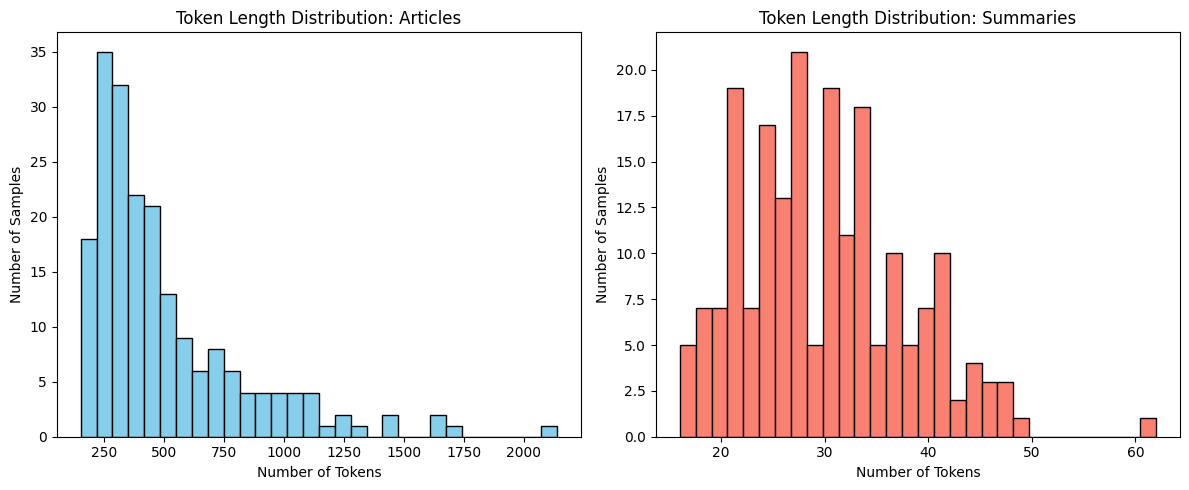

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Get token lengths
article_lengths = [len(tokenizer.encode(text, truncation=False)) for text in df["article"]]
summary_lengths = [len(tokenizer.encode(text, truncation=False)) for text in df["summary"]]

# Plotting
plt.figure(figsize=(12, 5))

# Article token lengths
plt.subplot(1, 2, 1)
plt.hist(article_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title("Token Length Distribution: Articles")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")

# Summary token lengths
plt.subplot(1, 2, 2)
plt.hist(summary_lengths, bins=30, color='salmon', edgecolor='black')
plt.title("Token Length Distribution: Summaries")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()